# **1. Исследование данных**

**Контекст задачи**: 

- Необходимо построить модель бинарной классификации для определения, является ли cookie_id ботом (1) или человеком (0).

**Ключевое ограничение на данные:** 

- Признаки строятся только из событий внутри окна `[window_start_ts, window_end_ts]`.

#### **Данные**

**1. train.csv / test.csv**:

* `cookie id` - идентификатор куки;

* `cookie_created_at` - время первого появления куки, которое может быть раньше начала окна наблюдения;

* `window_start_ts`, `window_end_ts` - начало и конец окна наблюдения.

**2. events.csv**

* `cookie_id` — идентификатор куки;

* `event_ts` - время события;

* `eid`, `event_name` - код и название типа события;

* `platform` - платформа;

* `user_agent` - строка User-Agent;

* `item_id`, `item_category`, `item_location`, `seller_type` - идентификатор объявления его категория локация и тип

* `search_query`, `search_page` - поисковый запрос и номер страницы выдачи;

* `pointer_x`, `pointer_y` - координаты курсора в момент события.

## **1.1. Загрузка данных и анализ структуры**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
DATA_DIR = Path("../data")

Загружаем `train.csv`, `test.csv`, `events.csv`:

In [32]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
events = pd.read_csv(DATA_DIR / "events.csv")

In [33]:
display(train.head())
print(f"\nТипы данных:\n{train.dtypes}")
print(f"\nПропуски:\n{train.isnull().sum()}")

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0



Типы данных:
cookie_id              str
cookie_created_at      str
window_start_ts        str
window_end_ts          str
target               int64
dtype: object

Пропуски:
cookie_id            0
cookie_created_at    0
window_start_ts      0
window_end_ts        0
target               0
dtype: int64


In [34]:
display(test.head())
print(f"\nПропуски:\n{test.isnull().sum()}")

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21



Пропуски:
cookie_id            0
cookie_created_at    0
window_start_ts      0
window_end_ts        0
dtype: int64


In [49]:
display(events.head())
print(f"\nТипы данных:\n{events.dtypes}")
print(f"\nПропуски:\n{events.isnull().sum()[events.isnull().sum() != 0]}")

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN



Типы данных:
cookie_id            str
event_ts             str
eid                int64
event_name           str
platform             str
user_agent           str
item_id          float64
item_category        str
item_location        str
seller_type          str
search_query         str
search_page      float64
pointer_x        float64
pointer_y        float64
dtype: object

Пропуски:
item_id          114597
item_category     32920
item_location     23793
seller_type      133853
search_query     228503
search_page      228503
pointer_x        220365
pointer_y        220365
dtype: int64


Приведем даты к верному формату:

In [50]:
for col in ["cookie_created_at", "window_start_ts", "window_end_ts"]:
    train[col] = pd.to_datetime(train[col])
    test[col] = pd.to_datetime(test[col])

events["event_ts"] = pd.to_datetime(events["event_ts"])

## **1.2. Анализ данных**

Первое, что необходимо проверить это насколько сбалансированы классы, поскольку это влияет на дальнейшее решение задачи:

Баланс классов:
  Класс 0 (человек): 10192 (91.89%)
  Класс 1 (бот): 899 (8.11%)


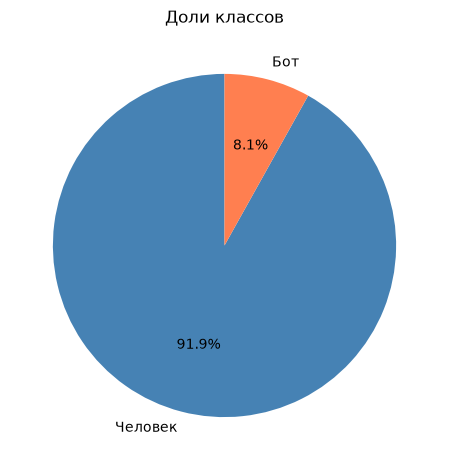

In [58]:
target_counts = train['target'].value_counts()
target_ratio = train['target'].mean()

print(f"Баланс классов:")
print(f"  Класс 0 (человек): {target_counts[0]} ({1-target_ratio:.2%})")
print(f"  Класс 1 (бот): {target_counts[1]} ({target_ratio:.2%})")

plt.pie([1-target_ratio, target_ratio], 
            labels=['Человек', 'Бот'],
            autopct='%1.1f%%',
            colors=['steelblue', 'coral'],
            startangle=90)
plt.title('Доли классов')

plt.tight_layout()
plt.show()

Заметим сильный дисбаланс классов в пользу класса 0 (человек). Будем иметь это ввиду при обучении.

Как сказано ранее, главным ограничением в данных является использование событий только внутри окна наблюдения. Поэтому далее логично будет проверить длительность окон.

In [60]:
train['window_duration_hours'] = (
    (train['window_end_ts'] - train['window_start_ts']).dt.total_seconds() / 3600
)

train['window_duration_hours'].describe()


count    11091.0
mean        24.0
std          0.0
min         24.0
25%         24.0
50%         24.0
75%         24.0
max         24.0
Name: window_duration_hours, dtype: float64

Как видим из вывода, все окна одинаковые и составляют целые 24 часа.

Следующим шагом, будем создание датафрейма, которой будет представлять собой объединение двух таблиц `train.csv` и `events.csv` по ключу `cookie_id`, а также с фильтрацией по окну, чтобы недопустить утечку данных.

In [61]:
# Объединяем события с окнами по cookie_id
train_windows = train[['cookie_id', 'window_start_ts', 'window_end_ts', 'target']].copy()
events_merged = events.merge(train_windows, on='cookie_id', how='inner')

# Фильтруем по времени
mask = (
    (events_merged['event_ts'] >= events_merged['window_start_ts']) &
    (events_merged['event_ts'] <= events_merged['window_end_ts'])
)
events_filtered = events_merged[mask].copy()

In [68]:
print(f"Количество событий до фильтрации: {len(events)}")
print(f"Количество событий после фильтрации: {len(events_filtered)}")
print(f"Уникальных cookie в отфильтрованных событиях: {events_filtered['cookie_id'].nunique()} из {len(train)}")

Количество событий до фильтрации: 328905
Количество событий после фильтрации: 198504
Уникальных cookie в отфильтрованных событиях: 11091 из 11091


### **1.2.1. Анализ количества событий**

Теперь имеем единую таблицу с `cookie_id` и связанные с ним событие, которые происходили строго в рамках окна. Проведем анализ количества событий на одну `cookie_id`. 

In [89]:
# Считаем количество событий для каждой куки (size() - считает количество строк для каждой куки)
event_counts = events_filtered.groupby('cookie_id').size().reset_index(name='event_count')
df_analysis = train.merge(event_counts, on='cookie_id', how='left')

print("Статистика для людей:\n")
print(df_analysis[df_analysis['target'] == 0]['event_count'].describe())

print("\nСтатистика для ботов:\n")
print(df_analysis[df_analysis['target'] == 1]['event_count'].describe())

Статистика для людей:

count    10192.000000
mean        16.875392
std         16.173568
min          1.000000
25%          6.000000
50%         12.000000
75%         22.000000
max        140.000000
Name: event_count, dtype: float64

Статистика для ботов:

count    899.000000
mean      29.488320
std       27.512391
min        1.000000
25%       11.000000
50%       20.000000
75%       38.000000
max      169.000000
Name: event_count, dtype: float64


Исходя из данного анализа, можешь сформировать гипотезу о том, что в среднем боты делают большее количество событий. Построим гистограмму распределения событий для визуального анализа:

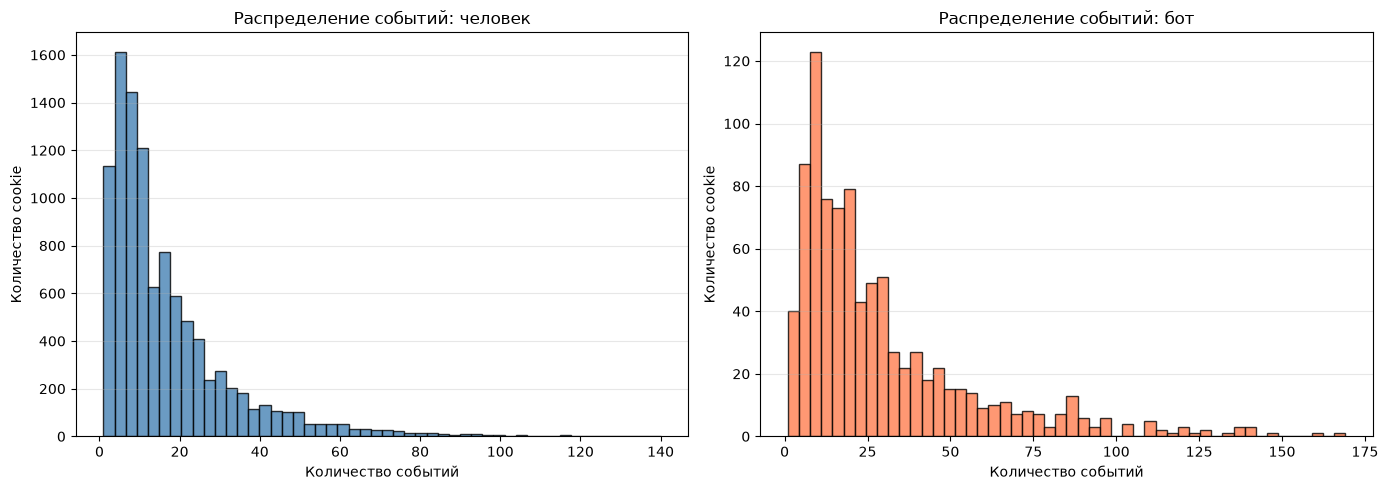

In [86]:
humans = df_analysis[df_analysis['target'] == 0]['event_count']
bots = df_analysis[df_analysis['target'] == 1]['event_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(humans, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Распределение событий: человек')
axes[0].set_xlabel('Количество событий')
axes[0].set_ylabel('Количество cookie')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(bots, bins=50, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Распределение событий: бот')
axes[1].set_xlabel('Количество событий')
axes[1].set_ylabel('Количество cookie')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Расределения имеют схожий характер, поэтому опираться лишь на количество событий для классификации недостаточно.

### **1.2.2. Анализ типов событий**